In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
ECG_DIR = Path("ECGDataDenoised")
archivos = sorted(ECG_DIR.glob("*.csv"))

print("Número de archivos encontrados:", len(archivos))

DIAG_DIR=Path("Diagnostics.xlsx")

Número de archivos encontrados: 10646


In [2]:
diag = pd.read_excel(DIAG_DIR)

print("Dimensión de Diagnostics:", diag.shape)
display(diag.head())
print("\nColumnas:")
print(diag.columns.tolist())

Dimensión de Diagnostics: (10646, 16)


,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354



Columnas:
['FileName', 'Rhythm', 'Beat', 'PatientAge', 'Gender', 'VentricularRate', 'AtrialRate', 'QRSDuration', 'QTInterval', 'QTCorrected', 'RAxis', 'TAxis', 'QRSCount', 'QOnset', 'QOffset', 'TOffset']


In [3]:
ecg = pd.read_csv(archivos[0])


fs = 500  

n_muestras = ecg.shape[0]
n_canales = ecg.shape[1]
duracion = n_muestras / fs

print("Número de registros:", len(archivos))
print("Número de canales:", n_canales)
print("Derivaciones:", ecg.columns.tolist())
print("Frecuencia de muestreo:", fs, "Hz")
print("Número de muestras:", n_muestras)
print("Duración:", duracion, "segundos")

Número de registros: 10646
Número de canales: 12
Derivaciones: ['-165.33', '-358.97', '-121.71', '270.25', '-28.869', '-231.16', '448.39', '636.52', '618.45', '-7.8987', '-315.16', '-570.84']
Frecuencia de muestreo: 500 Hz
Número de muestras: 4999
Duración: 9.998 segundos


Visualización y caracterización de las señales

In [ ]:
# Se seleccionan las aritmias de fibrilación auricular (AFIB) y taquicardia sinusal (ST), siempre que ambas estén presentes en tus datos.
afib = diag[diag["Rhythm"] == "AFIB"]
st = diag[diag["Rhythm"] == "ST"]

print("Registros AFIB:", len(afib))
print("Registros ST:", len(st))

# Seleccionar un registro de cada grupo

archivo_afib = ECG_DIR / (str(afib.iloc[0]["FileName"]) + ".csv")
archivo_st = ECG_DIR / (str(st.iloc[0]["FileName"]) + ".csv")

ecg_afib = pd.read_csv(archivo_afib)
ecg_st = pd.read_csv(archivo_st)

Registros AFIB: 1780
Registros ST: 1568


In [8]:
derivaciones = [
    "I", "II", "III",
    "aVR", "aVL", "aVF",
    "V1", "V2", "V3",
    "V4", "V5", "V6"
]

ecg_afib = pd.read_csv(
    archivo_afib,
    header=None,
    names=derivaciones
)

ecg_st = pd.read_csv(
    archivo_st,
    header=None,
    names=derivaciones
)

print(ecg_afib.shape)
print(ecg_st.shape)



(5000, 12)
(5000, 12)


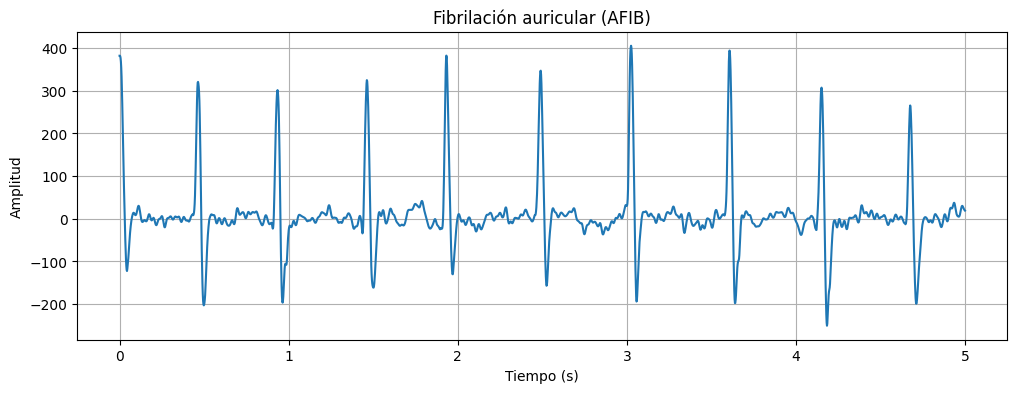

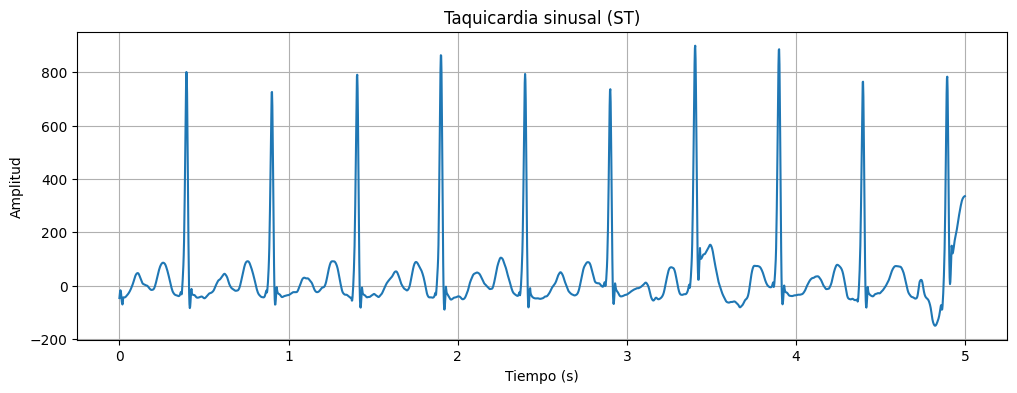

In [9]:
fs = 500

n = 5 * fs

t = np.arange(n) / fs

plt.figure(figsize=(12, 4))

plt.plot(t, ecg_afib["II"].iloc[:n])

plt.title("Fibrilación auricular (AFIB)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

plt.show()


plt.figure(figsize=(12, 4))

plt.plot(t, ecg_st["II"].iloc[:n])

plt.title("Taquicardia sinusal (ST)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

plt.show()

Análisis estadístico entre arritmias

In [16]:
from scipy.signal import find_peaks

def caracteristicas(archivo):

    ecg = pd.read_csv(archivo, header=None, names=derivaciones)

    señal = ecg["II"].to_numpy()

    media = np.mean(señal)

    desviacion = np.std(señal, ddof=1)

    maximo = np.max(señal)

    minimo = np.min(señal)

    rms = np.sqrt(np.mean(señal**2))

    # Detección preliminar de picos R
    picos, _ = find_peaks(
        señal,
        distance=int(0.3 * fs),
        prominence=np.std(señal)
    )

    if len(picos) > 1:

        intervalos_rr = np.diff(picos) / fs

        fc = 60 / np.mean(intervalos_rr)

    else:

        fc = np.nan

    return [media, desviacion, maximo, minimo, fc, rms]

resultados = []

for grupo, datos in [("AFIB", afib), ("ST", st)]:

    for nombre in datos["FileName"]:

        archivo = ECG_DIR / (str(nombre) + ".csv")

        if archivo.exists():

            valores = caracteristicas(archivo)

            resultados.append([nombre, grupo] + valores)


columnas = [
    "Archivo",
    "Arritmia",
    "Media",
    "Desviacion",
    "Maximo",
    "Minimo",
    "FC",
    "RMS"
]

df = pd.DataFrame(resultados, columns=columnas)

display(df.groupby("Arritmia").head(5))



,Archivo,Arritmia,Media,Desviacion,Maximo,Minimo,FC,RMS
0,MUSE_20180113_171327_27000,AFIB,8.630897,77.751527,450.15,-250.600,117.060481,78.221373
1,MUSE_20180114_075026_69000,AFIB,21.241662,77.967253,547.99,-112.970,97.959184,80.801516
2,MUSE_20180113_133901_16000,AFIB,6.864541,41.587275,313.92,-82.523,72.131148,42.145907
3,MUSE_20180116_123940_90000,AFIB,16.180496,103.870271,791.94,-364.620,79.348932,105.112719
4,MUSE_20180114_075003_61000,AFIB,12.833575,103.896434,664.12,-866.820,83.870968,104.675741
1780,MUSE_20180113_135023_96000,ST,31.140003,134.247571,899.13,-150.090,120.253165,137.798786
1781,MUSE_20180116_170254_89000,ST,32.345881,104.066523,644.04,-161.380,109.771847,108.967570
1782,MUSE_20180114_121405_34000,ST,38.107777,182.045786,1137.40,-291.280,106.649937,185.973768
1783,MUSE_20180119_173922_99000,ST,24.534453,122.754872,1241.20,-100.020,104.916684,125.170621
1784,MUSE_20180113_131104_16000,ST,13.607421,99.691744,530.97,-128.310,112.805515,100.606253
